KMeans: GSI=0.3492, PI=0.2881, SI=0.3235, Dunn=0.4214
Agglomerative: GSI=0.3123, PI=0.3285, SI=0.4745, Dunn=0.3687
DBSCAN: GSI=0.3630, PI=0.2657, SI=0.6436, Dunn=0.3635
Birch: GSI=nan, PI=nan, SI=nan, Dunn=nan
Fuzzy C-Means: GSI=0.3477, PI=0.3065, SI=0.4442, Dunn=0.3950
Mountain: GSI=0.3420, PI=0.3023, SI=0.4554, Dunn=0.3764
Improved Mountain: GSI=0.3484, PI=0.2561, SI=0.4291, Dunn=0.4177
Modified Mountain: GSI=0.3420, PI=0.3023, SI=0.4554, Dunn=0.3764
IMC-1: GSI=0.3484, PI=0.2561, SI=0.4291, Dunn=0.4177
IMC-2: GSI=0.3484, PI=0.2561, SI=0.4291, Dunn=0.4177


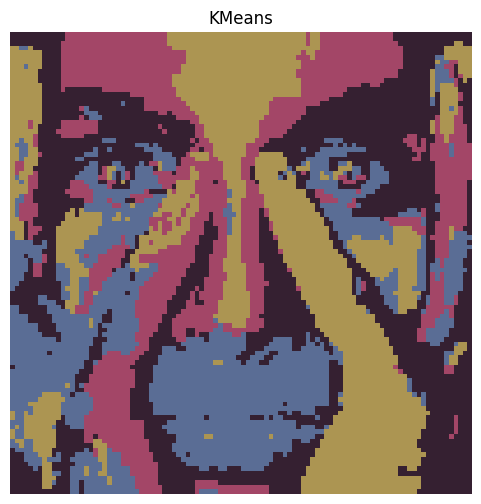

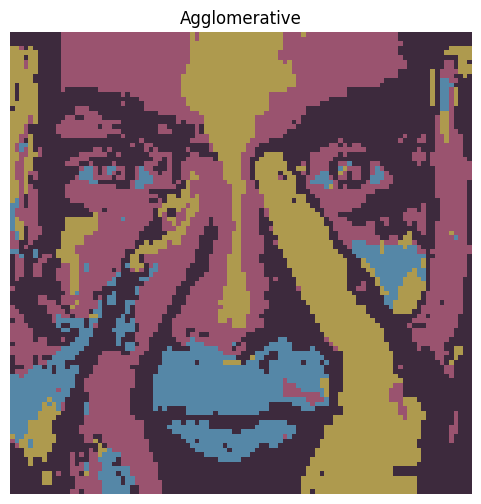

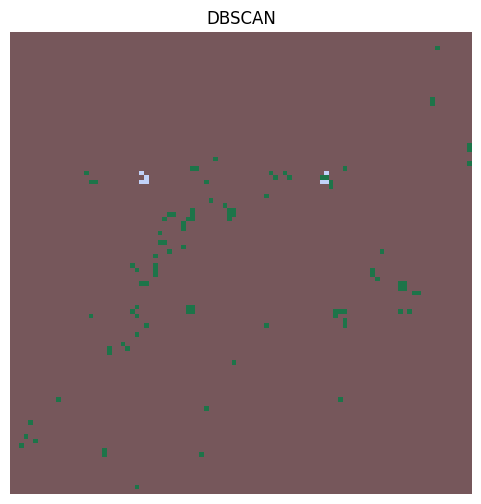

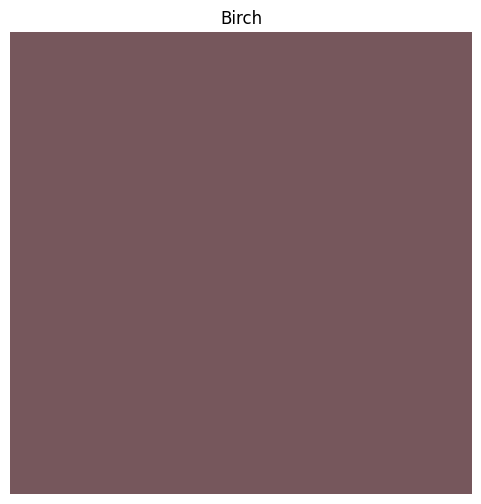

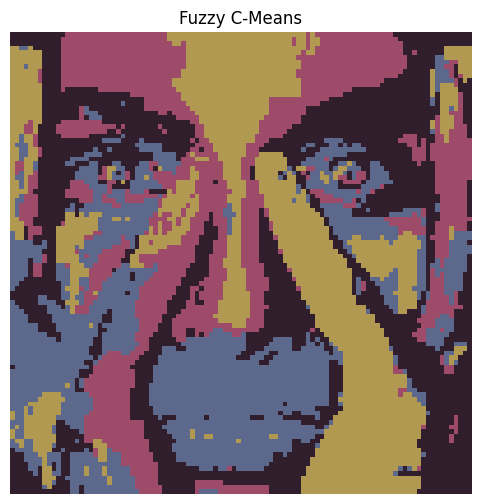

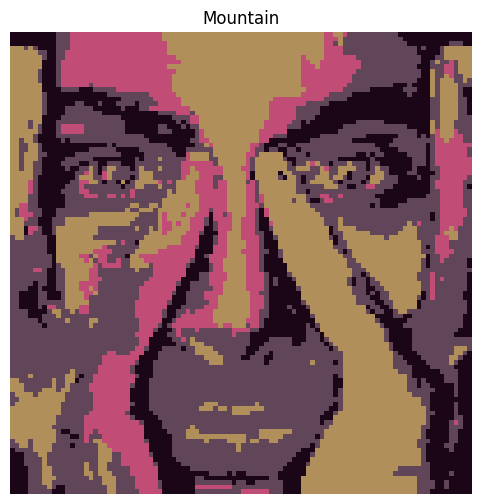

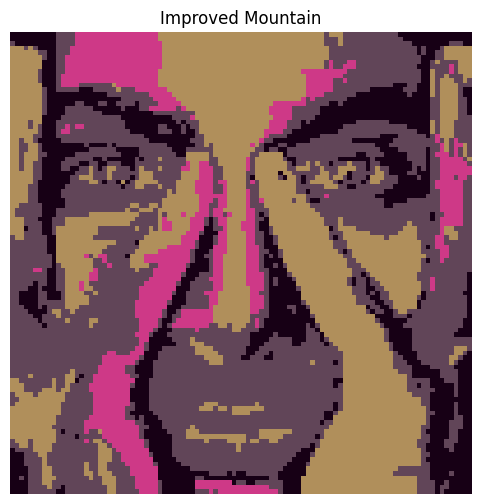

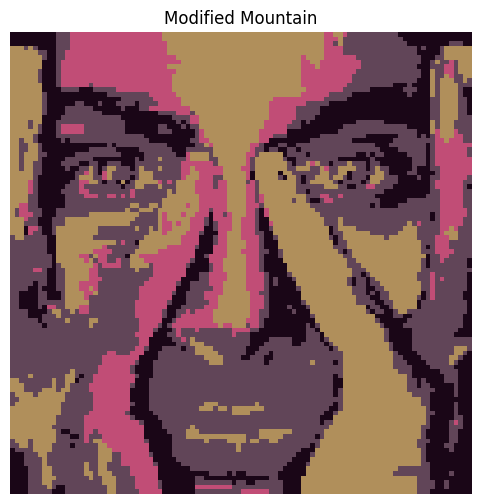

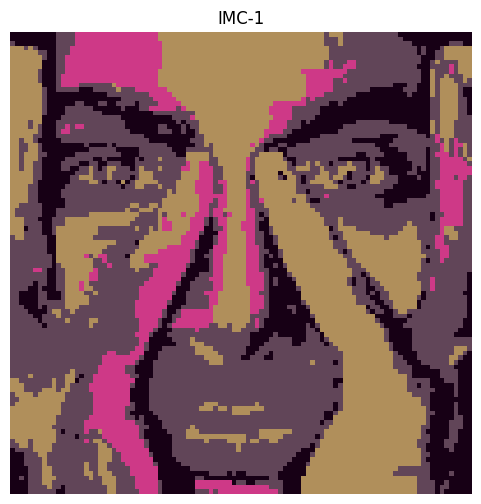

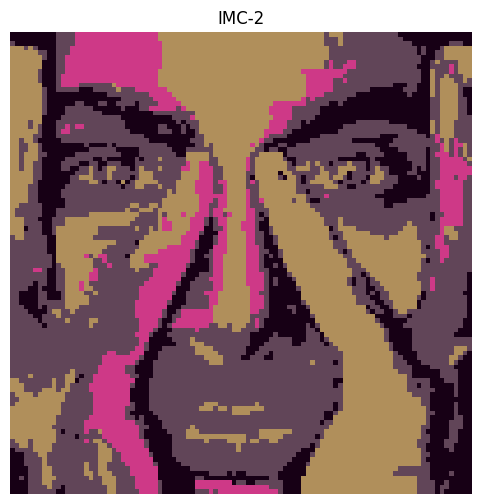

In [ ]:
import numpy as np
from skimage.io import imread, imshow
from skimage.color import rgb2lab
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, Birch
from skfuzzy import cmeans
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.spatial.distance import pdist, squareform
import warnings
import matplotlib.pyplot as plt
from skimage.color import lab2rgb


def load_and_preprocess(path):
    img = imread(path)
    lab = rgb2lab(img)
    H, W, _ = lab.shape
    X = lab.reshape(-1, 3)
    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    rng  = maxs - mins
    rng[rng == 0] = 1.0
    X_norm = (X - mins) / rng
    return img, X_norm, (H, W), (mins, rng)

def reindex_labels_and_centers(labels_orig, X):
    unique = np.unique(labels_orig[labels_orig >= 0])
    label_map = {lab:i for i, lab in enumerate(unique)}
    labels = np.array([ label_map.get(l, -1) for l in labels_orig ])
    centers = np.vstack([ X[labels == new].mean(axis=0) for new in range(len(unique)) ])
    return labels, centers


def cluster_kmeans(X, k):
    model = KMeans(n_clusters=k, random_state=0).fit(X)
    return model.labels_, model.cluster_centers_

def cluster_agglomerative(X, k):
    model = AgglomerativeClustering(n_clusters=k).fit(X)
    return reindex_labels_and_centers(model.labels_, X)

def cluster_dbscan(X, _):
    model = DBSCAN(eps=0.05, min_samples=5).fit(X)
    return reindex_labels_and_centers(model.labels_, X)

def cluster_birch(X, k):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = Birch(n_clusters=k).fit(X)
    return reindex_labels_and_centers(model.labels_, X)

def cluster_fuzzy_cmeans(X, k):
    cntr, u, _, _, _, _, _ = cmeans(X.T, c=k, m=2, error=1e-6, maxiter=200)
    labels = np.argmax(u, axis=0)
    return labels, cntr


def mountain_clustering(X, k, sigma=None, beta=None):
    if sigma is None: sigma = np.mean(np.std(X, axis=0))
    if beta  is None: beta  = sigma
    D2 = np.sum((X[:,None,:] - X[None,:,:])**2, axis=2)
    P  = np.sum(np.exp(-D2/(2*sigma**2)), axis=1)
    centers = []
    for _ in range(k):
        i = np.argmax(P); centers.append(X[i])
        P -= P[i] * np.exp(-np.sum((X - X[i])**2, axis=1)/(2*beta**2))
    centers = np.stack(centers)
    labels  = np.argmin(np.linalg.norm(X[:,None,:] - centers[None,:,:], axis=2), axis=1)
    return labels, centers

def improved_mountain_clustering(X, k, sigma=None, beta_factor=1.5):
    if sigma is None: sigma = np.mean(np.std(X, axis=0))
    D2 = np.sum((X[:,None,:] - X[None,:,:])**2, axis=2)
    P  = np.sum(np.exp(-D2/(2*sigma**2)), axis=1)
    centers = []; beta = sigma
    for _ in range(k):
        i = np.argmax(P); centers.append(X[i])
        P -= P[i] * np.exp(-np.sum((X - X[i])**2, axis=1)/(2*beta**2))
        beta *= beta_factor
    centers = np.stack(centers)
    labels  = np.argmin(np.linalg.norm(X[:,None,:] - centers[None,:,:], axis=2), axis=1)
    return labels, centers

def modified_mountain_clustering(X, k, sigma=None, beta=None, decay=0.9):
    if sigma is None: sigma = np.mean(np.std(X, axis=0))
    if beta  is None: beta  = sigma
    D2 = np.sum((X[:,None,:] - X[None,:,:])**2, axis=2)
    P  = np.sum(np.exp(-D2/(2*sigma**2)), axis=1)
    centers = []
    for _ in range(k):
        i = np.argmax(P); centers.append(X[i])
        P  = (P - P[i] * np.exp(-np.sum((X - X[i])**2, axis=1)/(2*beta**2))) * decay
    centers = np.stack(centers)
    labels  = np.argmin(np.linalg.norm(X[:,None,:] - centers[None,:,:], axis=2), axis=1)
    return labels, centers

def compute_delta1(X):
    ratios = np.min(X, axis=0) / (np.sum(X, axis=0) + 1e-16)
    return 0.5 * np.mean(ratios)

def compute_delta2(X, k):
    return compute_delta1(X) * (k / (k + 1))

def imc1(X, k, sigma=None, beta_factor=1.5):
    if sigma is None: sigma = np.mean(np.std(X, axis=0))
    D2 = np.sum((X[:,None,:] - X[None,:,:])**2, axis=2)
    P0 = np.sum(np.exp(-D2/(2*sigma**2)), axis=1)
    P  = P0 / (P0.max() + 1e-16)
    δ  = compute_delta1(X)
    centers = []; beta = sigma
    for _ in range(k):
        i = np.argmax(P)
        if P[i] < δ: break
        centers.append(X[i])
        P -= P[i] * np.exp(-np.sum((X - X[i])**2, axis=1)/(2*beta**2))
        beta *= beta_factor
    if not centers:
        centers = [X[np.argmax(P0)]]
    centers = np.stack(centers)
    labels  = np.argmin(np.linalg.norm(X[:,None,:] - centers[None,:,:], axis=2), axis=1)
    return labels, centers

def imc2(X, k, sigma=None, beta_factor=1.5):
    if sigma is None: sigma = np.mean(np.std(X, axis=0))
    D2 = np.sum((X[:,None,:] - X[None,:,:])**2, axis=2)
    P0 = np.sum(np.exp(-D2/(2*sigma**2)), axis=1)
    P  = P0 / (P0.max() + 1e-16)
    δ  = compute_delta2(X, k)
    centers = []; beta = sigma
    for _ in range(k):
        i = np.argmax(P)
        if P[i] < δ: break
        centers.append(X[i])
        P -= P[i] * np.exp(-np.sum((X - X[i])**2, axis=1)/(2*beta**2))
        beta *= beta_factor
    if not centers:
        centers = [X[np.argmax(P0)]]
    centers = np.stack(centers)
    labels  = np.argmin(np.linalg.norm(X[:,None,:] - centers[None,:,:], axis=2), axis=1)
    return labels, centers

from scipy.spatial.distance import pdist, squareform


def partition_index(X, labels, centers):

    M = centers.shape[0]
    PI = 0.0
    for m in range(M):
        idx_m = np.where(labels == m)[0]
        Nm = idx_m.size
        if Nm == 0:
            return np.nan

        num = np.sum(np.linalg.norm(X[idx_m] - centers[m], axis=1)**2)

        denom = Nm * np.sum(np.linalg.norm(centers - centers[m], axis=1)**2)
        if denom == 0:
            return np.nan
        PI += num / denom
    return PI

def separation_index(X, labels, centers):

    M = centers.shape[0]
    n = X.shape[0]


    total_wss = 0.0
    for m in range(M):
        idx_m = np.where(labels == m)[0]
        if idx_m.size == 0:
            return np.nan
        total_wss += np.sum(np.linalg.norm(X[idx_m] - centers[m], axis=1)**2)


    c_d2 = squareform(pdist(centers, 'euclidean'))**2
    np.fill_diagonal(c_d2, np.inf)
    min_sq = c_d2.min()
    if min_sq == np.inf:
        return np.nan

    return total_wss / (n * min_sq)

def dunn_index(X, labels, centers):

    M = centers.shape[0]


    diameters = []
    for m in range(M):
        idx_m = np.where(labels == m)[0]
        if idx_m.size > 1:
            pts = X[idx_m]
            diam = pdist(pts, 'euclidean').max()
        else:
            diam = 0.0
        diameters.append(diam)
    max_diam = max(diameters)
    if max_diam == 0:
        return np.nan


    inter_vals = []
    for m in range(M):
        idx_m = np.where(labels == m)[0]
        Xm = X[idx_m]
        for k in range(m+1, M):
            idx_k = np.where(labels == k)[0]
            Xk = X[idx_k]
            if idx_m.size == 0 or idx_k.size == 0:
                continue
            vm = centers[m]
            vk = centers[k]
            sum_m = np.sum(np.linalg.norm(Xm - vk, axis=1))
            sum_k = np.sum(np.linalg.norm(Xk - vm, axis=1))
            inter = (sum_m + sum_k) / (idx_m.size + idx_k.size)
            inter_vals.append(inter)

    if not inter_vals:
        return np.nan

    min_inter = min(inter_vals)
    return min_inter / max_diam




def compute_metrics(X, labels, centers):
    M = centers.shape[0]
    n = X.shape[0]
    metrics = {}

    min_x = X.min(axis=0)
    max_x = X.max(axis=0)
    rng   = max_x - min_x
    rng[rng == 0] = 1.0
    Xn = (X - min_x) / rng


    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)
    if 2 <= n_clusters <= n - 1:
        s_vals = silhouette_samples(Xn, labels, metric='euclidean')
        S_cluster = {lab: np.mean(s_vals[labels == lab]) for lab in unique_labels}
        GSI = np.mean(list(S_cluster.values()))
    else:
        S_cluster = {lab: np.nan for lab in unique_labels}
        GSI = np.nan

    metrics['Silhouette_per_cluster'] = S_cluster
    metrics['GSI'] = GSI

    metrics['PI'] = partition_index(X, labels, centers)

    metrics['SI'] = separation_index(X, labels, centers)

    metrics['Dunn'] = dunn_index(X, labels, centers)

    return metrics


def segment_and_evaluate(path, k):
    img_raw, X_norm, (H, W), (mins, rng) = load_and_preprocess(path)
    methods = {
        'KMeans':            cluster_kmeans,
        'Agglomerative':     cluster_agglomerative,
        'DBSCAN':            cluster_dbscan,
        'Birch':             cluster_birch,
        'Fuzzy C-Means':     cluster_fuzzy_cmeans,
        'Mountain':          mountain_clustering,
        'Improved Mountain': improved_mountain_clustering,
        'Modified Mountain': modified_mountain_clustering,
        'IMC-1':             imc1,
        'IMC-2':             imc2,
    }
    results = {}
    for name, fn in methods.items():
        labels, centers_norm = fn(X_norm, k)
        centers_lab = centers_norm * rng + mins
        segmented = centers_lab[labels].reshape(H, W, 3)
        metrics   = compute_metrics(X_norm, labels, centers_norm)
        results[name] = {
            'segmentation_lab': segmented,
            **metrics
        }
    return results


if __name__ == '__main__':
    res = segment_and_evaluate('e3.jpg', 4)
    H, W = res[next(iter(res))]['segmentation_lab'].shape[:2]

    for name, info in res.items():
        print(f"{name}: GSI={info['GSI']:.4f}, PI={info['PI']:.4f}, "
              f"SI={info['SI']:.4f}, Dunn={info['Dunn']:.4f}")


        lab_seg = info['segmentation_lab'].reshape(H, W, 3)
        rgb_seg = lab2rgb(lab_seg)

        plt.figure(figsize=(6,6))
        plt.title(name)
        plt.imshow(rgb_seg)
        plt.axis('off')

    plt.show()